In [1]:
import pandas as pd
print("Pandas is working")

Pandas is working


In [2]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Deepalakshmi\Downloads\sample_emails.csv")
print(df.head())

   id                sender                     subject  \
0   1        hr@company.com  Offer Letter - Please Sign   
1   2  noreply@shopping.com    Big Billion Sale is Live   
2   3     alerts@mybank.com       Unusual Login Attempt   
3   4   newsletter@blog.com      Weekly Tech Newsletter   
4   5   friend123@gmail.com        Coffee this weekend?   

                                                body priority       label  
0  Dear Candidate, Congratulations! Please sign a...     high   important  
1  Flat 70% OFF on electronics. Limited period of...      low   promotion  
2  We detected a login attempt to your account fr...     high    security  
3  In this week's edition, learn about AI agents,...      low  newsletter  
4  Hey, long time no see! Are you free this weeke...   medium    personal  


In [3]:
df.info

<bound method DataFrame.info of    id                  sender                                subject  \
0   1          hr@company.com             Offer Letter - Please Sign   
1   2    noreply@shopping.com               Big Billion Sale is Live   
2   3       alerts@mybank.com                  Unusual Login Attempt   
3   4     newsletter@blog.com                 Weekly Tech Newsletter   
4   5     friend123@gmail.com                   Coffee this weekend?   
5   6  spam@strange-domain.ru                  You won $1,000,000!!!   
6   7     manager@company.com                Project Update Required   
7   8        training@lms.com  Reminder: Complete Mandatory Training   

                                                body priority       label  
0  Dear Candidate, Congratulations! Please sign a...     high   important  
1  Flat 70% OFF on electronics. Limited period of...      low   promotion  
2  We detected a login attempt to your account fr...     high    security  
3  In this week

In [4]:
df.describe(include="all")

,id,sender,subject,body,priority,label
count,8.00000,8,8,8,8,8
unique,NaN,8,8,8,3,7
top,NaN,hr@company.com,Offer Letter - Please Sign,"Dear Candidate, Congratulations! Please sign a...",high,work
freq,NaN,1,1,1,4,2
mean,4.50000,NaN,NaN,NaN,NaN,NaN
std,2.44949,NaN,NaN,NaN,NaN,NaN
min,1.00000,NaN,NaN,NaN,NaN,NaN
25%,2.75000,NaN,NaN,NaN,NaN,NaN
50%,4.50000,NaN,NaN,NaN,NaN,NaN
75%,6.25000,NaN,NaN,NaN,NaN,NaN


In [5]:
df["label"].value_counts()

label
work          2
promotion     1
important     1
security      1
newsletter    1
personal      1
spam          1
Name: count, dtype: int64

In [6]:
df.fillna("")

,id,sender,subject,body,priority,label
0,1,hr@company.com,Offer Letter - Please Sign,"Dear Candidate, Congratulations! Please sign a...",high,important
1,2,noreply@shopping.com,Big Billion Sale is Live,Flat 70% OFF on electronics. Limited period of...,low,promotion
2,3,alerts@mybank.com,Unusual Login Attempt,We detected a login attempt to your account fr...,high,security
3,4,newsletter@blog.com,Weekly Tech Newsletter,"In this week's edition, learn about AI agents,...",low,newsletter
4,5,friend123@gmail.com,Coffee this weekend?,"Hey, long time no see! Are you free this weeke...",medium,personal
5,6,spam@strange-domain.ru,"You won $1,000,000!!!",Click here to claim your lottery now. Do not s...,high,spam
6,7,manager@company.com,Project Update Required,Please share the status update of your project...,high,work
7,8,training@lms.com,Reminder: Complete Mandatory Training,Your mandatory security awareness training is ...,medium,work


In [7]:
#Clean text + handle missing values
df = df.fillna("")
df['subject'] = df['subject'].str.lower().str.strip()
df['body'] = df['body'].str.lower().str.strip()
print(df)

   id                  sender                                subject  \
0   1          hr@company.com             offer letter - please sign   
1   2    noreply@shopping.com               big billion sale is live   
2   3       alerts@mybank.com                  unusual login attempt   
3   4     newsletter@blog.com                 weekly tech newsletter   
4   5     friend123@gmail.com                   coffee this weekend?   
5   6  spam@strange-domain.ru                  you won $1,000,000!!!   
6   7     manager@company.com                project update required   
7   8        training@lms.com  reminder: complete mandatory training   

                                                body priority       label  
0  dear candidate, congratulations! please sign a...     high   important  
1  flat 70% off on electronics. limited period of...      low   promotion  
2  we detected a login attempt to your account fr...     high    security  
3  in this week's edition, learn about ai agent

In [8]:
# 2. Create combined text column
df['combined'] = df['subject'] + " " + df['body']


print(df)

   id                  sender                                subject  \
0   1          hr@company.com             offer letter - please sign   
1   2    noreply@shopping.com               big billion sale is live   
2   3       alerts@mybank.com                  unusual login attempt   
3   4     newsletter@blog.com                 weekly tech newsletter   
4   5     friend123@gmail.com                   coffee this weekend?   
5   6  spam@strange-domain.ru                  you won $1,000,000!!!   
6   7     manager@company.com                project update required   
7   8        training@lms.com  reminder: complete mandatory training   

                                                body priority       label  \
0  dear candidate, congratulations! please sign a...     high   important   
1  flat 70% off on electronics. limited period of...      low   promotion   
2  we detected a login attempt to your account fr...     high    security   
3  in this week's edition, learn about ai a

In [9]:
# 3. Filter example (messages containing 'otp')
offer_only = df[df['combined'].str.contains("offer")]


print(df)
print("\nOffer Messages:")
print(offer_only)

   id                  sender                                subject  \
0   1          hr@company.com             offer letter - please sign   
1   2    noreply@shopping.com               big billion sale is live   
2   3       alerts@mybank.com                  unusual login attempt   
3   4     newsletter@blog.com                 weekly tech newsletter   
4   5     friend123@gmail.com                   coffee this weekend?   
5   6  spam@strange-domain.ru                  you won $1,000,000!!!   
6   7     manager@company.com                project update required   
7   8        training@lms.com  reminder: complete mandatory training   

                                                body priority       label  \
0  dear candidate, congratulations! please sign a...     high   important   
1  flat 70% off on electronics. limited period of...      low   promotion   
2  we detected a login attempt to your account fr...     high    security   
3  in this week's edition, learn about ai a

In [10]:
important_only = df[df['label'].str.contains("important")]
print(important_only)

   id          sender                     subject  \
0   1  hr@company.com  offer letter - please sign   

                                                body priority      label  \
0  dear candidate, congratulations! please sign a...     high  important   

                                            combined  
0  offer letter - please sign dear candidate, con...  


In [11]:
df.shape

(8, 7)

In [12]:
df.isnull().sum()

id          0
sender      0
subject     0
body        0
priority    0
label       0
combined    0
dtype: int64

In [13]:
print(df['subject'][0])

offer letter - please sign


In [14]:
df['priority'].value_counts()

priority
high      4
low       2
medium    2
Name: count, dtype: int64

In [15]:
df['clean_txt']=df['body'].str.lower().str.replace('[^a-zA-Z]','',regex=True)
df[['body','clean_txt']].head()

,body,clean_txt
0,"dear candidate, congratulations! please sign a...",dearcandidatecongratulationspleasesignanduploa...
1,flat 70% off on electronics. limited period of...,flatoffonelectronicslimitedperiodoffervisitour...
2,we detected a login attempt to your account fr...,wedetectedaloginattempttoyouraccountfromanewde...
3,"in this week's edition, learn about ai agents,...",inthisweekseditionlearnaboutaiagentslanggrapha...
4,"hey, long time no see! are you free this weeke...",heylongtimenoseeareyoufreethisweekendforcoffee


In [16]:
from collections import Counter
all_words ="".join(df['clean_txt']).split()
word_freq = Counter(all_words)
word_freq.most_common(3)

[('dearcandidatecongratulationspleasesignanduploadyourofferletterbytodayeveningflatoffonelectronicslimitedperiodoffervisitourstorenowwedetectedaloginattempttoyouraccountfromanewdeviceifthiswasnotyoupleaseresetyourpasswordinthisweekseditionlearnaboutaiagentslanggraphandmoreheylongtimenoseeareyoufreethisweekendforcoffeeclickheretoclaimyourlotterynowdonotsharethiswithanyonepleasesharethestatusupdateofyourprojectbeforepmtodayyourmandatorysecurityawarenesstrainingisduetomorrow',
  1)]

In [17]:
all_words_text=" ".join(df['clean_txt']).split()

In [18]:
words=all_words_text

In [19]:
len(words)

8

In [20]:
import nltk 
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))
filtered_words=[w for w in words if w not in stop_words]


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Deepalakshmi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [21]:
pip install nltk

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
import re

df['clean_text'] = (
    df['body']
    .str.lower()                              
    .str.replace(r'[^a-z\s]', '', regex=True) 
    .str.replace(r'\s+', ' ', regex=True)     
    .str.strip()
)
print(df['clean_text'])

0    dear candidate congratulations please sign and...
1    flat off on electronics limited period offer v...
2    we detected a login attempt to your account fr...
3    in this weeks edition learn about ai agents la...
4    hey long time no see are you free this weekend...
5    click here to claim your lottery now do not sh...
6    please share the status update of your project...
7    your mandatory security awareness training is ...
Name: clean_text, dtype: object


In [23]:
import nltk

nltk.download('punkt')
nltk.download('stopwords')


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Deepalakshmi\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Deepalakshmi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [24]:
from nltk.tokenize import wordpunct_tokenize

def remove_stopwords(text):
    if not isinstance(text, str):
        return ""
    words = wordpunct_tokenize(text.lower())
    return " ".join([w for w in words if w.isalpha() and w not in stop_words])

df['clean_text'] = df['body'].fillna("").apply(remove_stopwords)


In [25]:
print(df['clean_text'])

0    dear candidate congratulations please sign upl...
1    flat electronics limited period offer visit store
2    detected login attempt account new device plea...
3               week edition learn ai agents langgraph
4                hey long time see free weekend coffee
5                     click claim lottery share anyone
6          please share status update project pm today
7    mandatory security awareness training due tomo...
Name: clean_text, dtype: object


In [26]:
df['clean_text'].head(3)


0    dear candidate congratulations please sign upl...
1    flat electronics limited period offer visit store
2    detected login attempt account new device plea...
Name: clean_text, dtype: object

In [27]:
from collections import Counter

# Combine 
all_words = " ".join(df['clean_text']).split()

# Count word frequency
word_freq = Counter(all_words)

# Convert to DataFrame
word_freq_df = (
    pd.DataFrame(word_freq.items(), columns=['Word', 'Frequency'])
    .sort_values(by='Frequency', ascending=False)
)

# Show top 10 words
word_freq_df.head(10)


,Word,Frequency
3,please,3
6,offer,2
8,today,2
40,share,2
2,congratulations,1
1,candidate,1
5,upload,1
4,sign,1
7,letter,1
9,evening,1


In [28]:
from collections import Counter
all_words = " ".join(df['clean_text']).split()
word_freq = Counter(all_words)
word_freq_df = (pd.DataFrame(word_freq.items(), columns=['Word', 'Frequency'])
                .sort_values(by='Frequency', ascending=False))
word_freq_df.head()


,Word,Frequency
3,please,3
6,offer,2
8,today,2
40,share,2
2,congratulations,1


In [29]:
from nltk.stem import PorterStemmer

In [30]:
ps=PorterStemmer()
df['stemmed_text'] = df['clean_text'].apply(
    lambda x: "".join(ps.stem(w) for w in x.split())
)
print(df[['clean_text','stemmed_text']].head())

                                          clean_text  \
0  dear candidate congratulations please sign upl...   
1  flat electronics limited period offer visit store   
2  detected login attempt account new device plea...   
3             week edition learn ai agents langgraph   
4              hey long time see free weekend coffee   

                                        stemmed_text  
0  dearcandidcongratulpleassignuploadofferlettert...  
1             flatelectronlimitperiodoffervisitstore  
2  detectloginattemptaccountnewdevicpleasresetpas...  
3                      weekeditlearnaiagentlanggraph  
4                     heylongtimeseefreeweekendcoffe  


In [31]:
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()
df['lemmatized_text']=df['clean_text'].apply(
    lambda x:"".join(lemmatizer.lemmatize(word) for word in x.split())

)
df[['clean_text','lemmatized_text']].head()


,clean_text,lemmatized_text
0,dear candidate congratulations please sign upl...,dearcandidatecongratulationpleasesignuploadoff...
1,flat electronics limited period offer visit store,flatelectronicslimitedperiodoffervisitstore
2,detected login attempt account new device plea...,detectedloginattemptaccountnewdevicepleaserese...
3,week edition learn ai agents langgraph,weekeditionlearnaiagentlanggraph
4,hey long time see free weekend coffee,heylongtimeseefreeweekendcoffee


In [32]:
import nltk
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Deepalakshmi\AppData\Roaming\nltk_data...


[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Deepalakshmi\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [33]:
#Keyword_Extraction
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()
X = tfidf.fit_transform(df['clean_text'])

keywords = tfidf.get_feature_names_out()
print(keywords[:15])

['account' 'agents' 'ai' 'anyone' 'attempt' 'awareness' 'candidate'
 'claim' 'click' 'coffee' 'congratulations' 'dear' 'detected' 'device'
 'due']


In [34]:
spam_words = [
    'click', 'claim', 'free', 'offer', 'lottery',
    'winner', 'congratulations', 'prize', 'share'
]

df['is_spam'] = df['clean_text'].apply(
    lambda text: any(word in text.split() for word in spam_words)
)

df[['clean_text', 'is_spam']]

,clean_text,is_spam
0,dear candidate congratulations please sign upl...,True
1,flat electronics limited period offer visit store,True
2,detected login attempt account new device plea...,False
3,week edition learn ai agents langgraph,False
4,hey long time see free weekend coffee,True
5,click claim lottery share anyone,True
6,please share status update project pm today,True
7,mandatory security awareness training due tomo...,False


In [35]:
def detect_spam(text):
    count = sum(word in text.split() for word in spam_words)
    return count >= 2 # spam only if 2+ spam words

df['is_spam_improved'] = df['clean_text'].apply(detect_spam)
df[['clean_text', 'is_spam_improved']]

,clean_text,is_spam_improved
0,dear candidate congratulations please sign upl...,True
1,flat electronics limited period offer visit store,False
2,detected login attempt account new device plea...,False
3,week edition learn ai agents langgraph,False
4,hey long time see free weekend coffee,False
5,click claim lottery share anyone,True
6,please share status update project pm today,False
7,mandatory security awareness training due tomo...,False


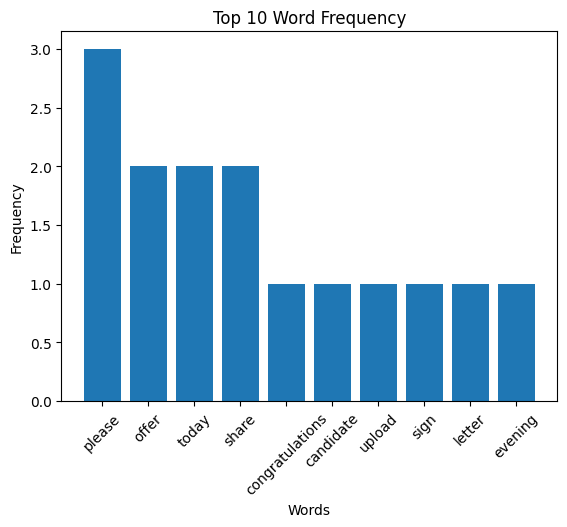

In [36]:
import matplotlib.pyplot as plt

# Top 10 words
top_words = word_freq_df.head(10)

plt.figure()
plt.bar(top_words['Word'], top_words['Frequency'])
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.title('Top 10 Word Frequency')
plt.xticks(rotation=45)
plt.show()

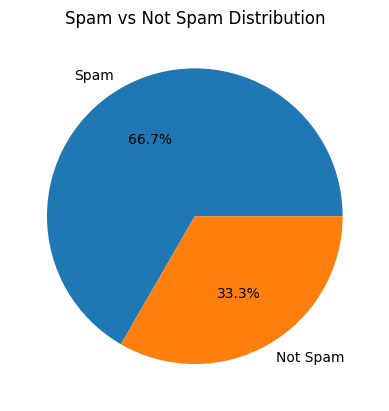

In [37]:
spam_counts1 = df['is_spam_improved'].head(3).value_counts()

plt.figure()
plt.pie(
    spam_counts1,
    labels=['Spam', 'Not Spam'],
    autopct='%1.1f%%'
)
plt.title('Spam vs Not Spam Distribution')
plt.show()

In [38]:
# Combine subject + body
df["combined_text"] = (df["subject"] + " " + df["body"]).str.lower()

# Updated category dictionary (slightly different keywords)
categories = {
    "important": ["offer letter", "action required", "please sign", "upload document"],
    "promotion": ["discount", "limited time", "save", "mega sale", "special offer"],
    "security": ["password reset", "blocked", "unauthorized", "suspicious", "verification"],
    "newsletter": ["newsletter", "digest", "update", "weekly edition"],
    "personal": ["coffee", "weekend", "catch up", "long time no see"],
    "spam": ["lottery", "winner", "claim reward", "click", "urgent prize"],
    "work": ["deadline", "project update", "training", "meeting", "follow-up"]
}

# Modified detection function
def detect_categories(text):
    text = text.lower()
    found = []

    for category, keywords in categories.items():
        if any(keyword in text for keyword in keywords):
            found.append(category)
    return found

# Apply category detection
df["detected_categories"] = df["combined_text"].apply(detect_categories)
df["match_count"] = df["detected_categories"].apply(len)

# Compute category frequency
from collections import Counter
cat_counter = Counter()

for row in df["detected_categories"]:
    cat_counter.update(row)

# Sort categories by count
cat_counter = dict(sorted(cat_counter.items(), key=lambda x: x[1], reverse=True))

cat_counter


{'newsletter': 2, 'work': 2, 'important': 1, 'personal': 1, 'spam': 1}

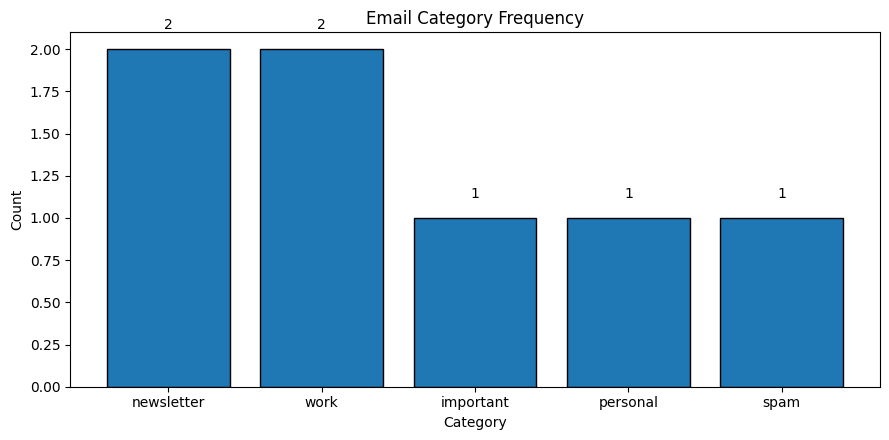

In [40]:
import matplotlib.pyplot as plt

# Sort categories by frequency
items = sorted(cat_counter.items(), key=lambda x: x[1], reverse=True)
labels = [x[0] for x in items]
values = [x[1] for x in items]

plt.figure(figsize=(9, 4.5))
bars = plt.bar(labels, values, edgecolor='black')

plt.title("Email Category Frequency")
plt.xlabel("Category")
plt.ylabel("Count")

# Label each bar with its count
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.1,
        str(int(height)),
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()


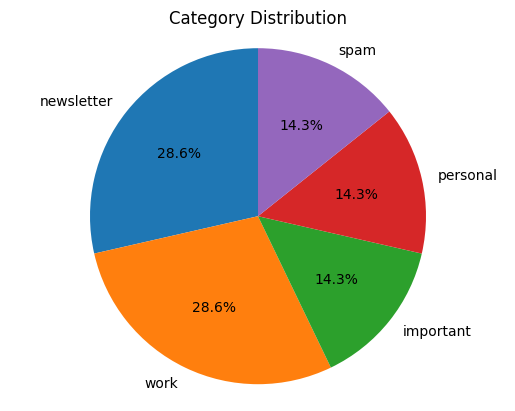

In [42]:
items = sorted(cat_counter.items(), key=lambda x: x[1], reverse=True)
cats = [c for c, _ in items]
vals = [v for _, v in items]

plt.pie(vals, labels=cats, autopct="%1.1f%%", startangle=90)
plt.title("Category Distribution")
plt.axis("equal")
plt.show()


In [46]:
df["combined"] = (df["subject"] + " " + df["body"]).str.lower()

def detect_simple(text):
    matches = []
    for cat, keys in categories.items():
        for k in keys:
            if k in text:
                matches.append(cat)
                break
    return matches

df["matched"] = df["combined"].apply(detect_simple)




In [48]:
import re
from collections import Counter

stopwords = {
 "the","and","is","in","to","of","for","a","an","by","on","this","that",
 "with","your","please","we","our"
}

top5_per_category = {}

for cat in categories:
    # filter rows where category is present
    texts = df[df["matched"].apply(lambda x: cat in x)]["combined"].tolist()

    words = []
    for t in texts:
        tokens = re.findall(r"[a-z]+", t.lower())
        tokens = [w for w in tokens if w not in stopwords]
        words.extend(tokens)

    # top 5
    top5_per_category[cat] = [w for w, _ in Counter(words).most_common(5)]

top5_per_category



{'important': ['offer', 'letter', 'sign', 'dear', 'candidate'],
 'promotion': [],
 'security': [],
 'newsletter': ['project', 'update', 'weekly', 'tech', 'newsletter'],
 'personal': ['coffee', 'weekend', 'hey', 'long', 'time'],
 'spam': ['you', 'won', 'click', 'here', 'claim'],
 'work': ['project', 'update', 'mandatory', 'training', 'required']}